# Task 1 : Environment Setup, Imports, Data Loading, EDA & Feature Engineering

In [ ]:
!pip install prophet
!pip install xgboost
!pip install statsmodels

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.style.use("ggplot")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv
Saving vgsales.csv to vgsales (1).csv


In [ ]:
sales = pd.read_csv("train.csv")
games = pd.read_csv("vgsales.csv")

In [ ]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
print("Sales Dataset Shape :", sales.shape)
print("Games Dataset Shape :", games.shape)

Sales Dataset Shape : (9800, 18)
Games Dataset Shape : (16598, 11)


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
sales.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [ ]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
sales.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


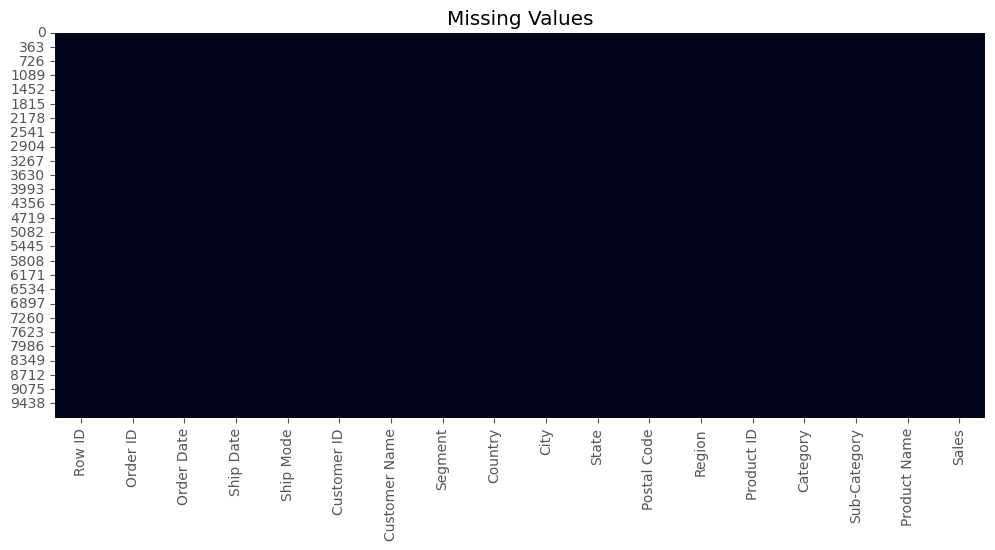

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(sales.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

In [ ]:
sales.duplicated().sum()

np.int64(0)

In [ ]:
sales.drop_duplicates(inplace=True)

In [ ]:
sales["Order Date"].head(10)

,Order Date
0,08/11/2017
1,08/11/2017
2,12/06/2017
3,11/10/2016
4,11/10/2016
5,09/06/2015
6,09/06/2015
7,09/06/2015
8,09/06/2015
9,09/06/2015


In [ ]:
sales["Order Date"] = pd.to_datetime(
    sales["Order Date"],
    dayfirst=True
)

sales["Ship Date"] = pd.to_datetime(
    sales["Ship Date"],
    dayfirst=True
)

In [ ]:
sales.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
sales["Year"] = sales["Order Date"].dt.year

sales["Month"] = sales["Order Date"].dt.month

sales["Month Name"] = sales["Order Date"].dt.month_name()

sales["Quarter"] = sales["Order Date"].dt.quarter

sales["Week"] = sales["Order Date"].dt.isocalendar().week

sales["Day"] = sales["Order Date"].dt.day_name()

In [ ]:
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

sales["Season"] = sales["Month"].apply(season)

In [ ]:
sales["Shipping Days"] = (
    sales["Ship Date"] -
    sales["Order Date"]
).dt.days

In [ ]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,Monsoon,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,Autumn,7


In [ ]:
print("Total Sales")
print(f"${sales['Sales'].sum():,.2f}")

Total Sales
$2,261,536.78


In [ ]:
print("Total Orders")
print(sales["Order ID"].nunique())

Total Orders
4922


In [ ]:
print("Total Customers")
print(sales["Customer ID"].nunique())

Total Customers
793


In [ ]:
print("Total Products")
print(sales["Product ID"].nunique())

Total Products
1861


In [ ]:
category_sales = sales.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


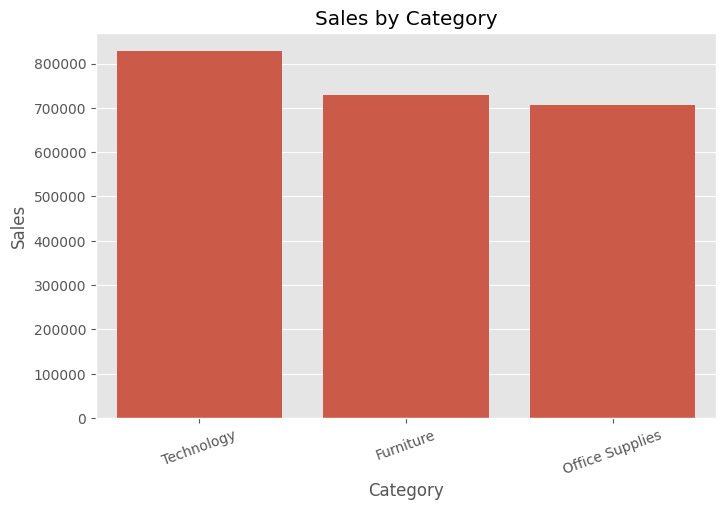

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=20)

plt.show()

In [ ]:
highest = category_sales.idxmax()

print("Highest Revenue Category :", highest)

Highest Revenue Category : Technology


In [ ]:
region_sales = sales.groupby("Region")["Sales"].sum()

region_sales

,Sales
Region,
Central,492646.9132
East,669518.7260
South,389151.4590
West,710219.6845


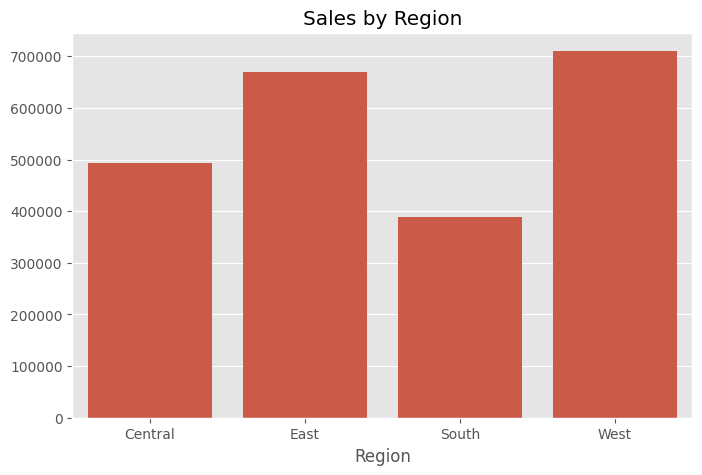

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")

plt.show()

In [ ]:
growth = sales.groupby(
    ["Year","Region"]
)["Sales"].sum().reset_index()

growth

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


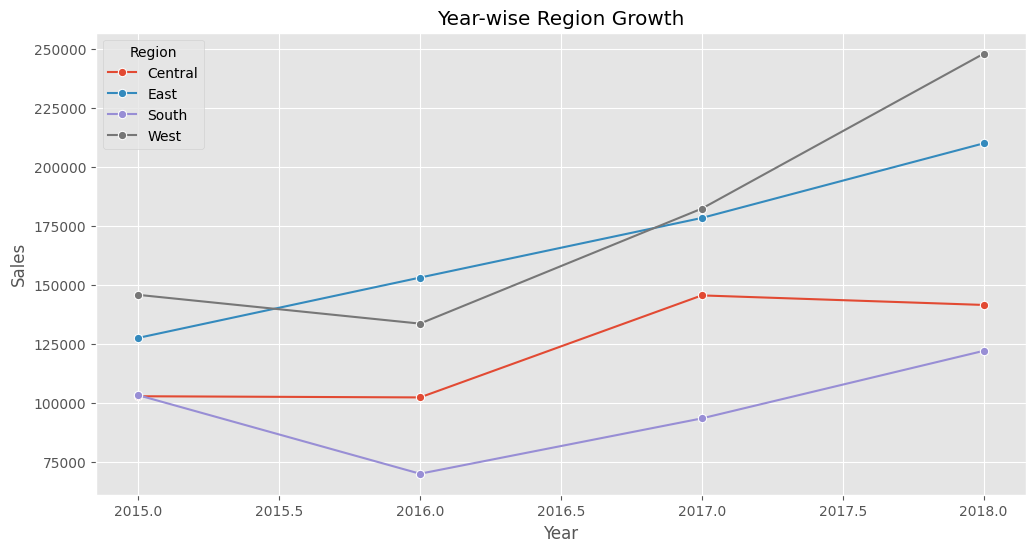

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=growth,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Year-wise Region Growth")

plt.show()

In [ ]:
shipping = sales.groupby("Region")["Shipping Days"].mean()

shipping

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


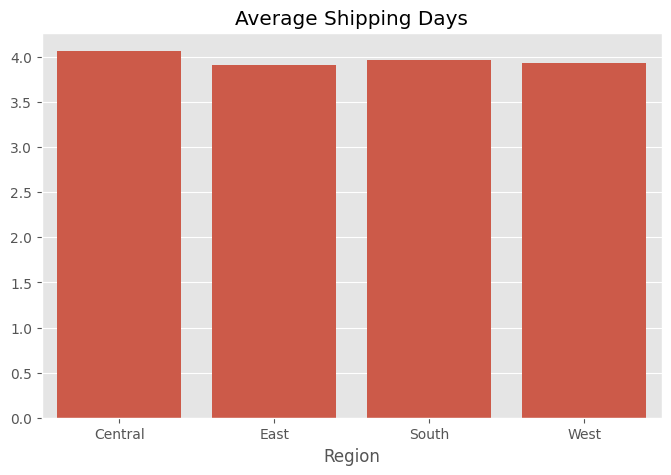

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping.index,
    y=shipping.values
)

plt.title("Average Shipping Days")

plt.show()

In [ ]:
monthly_sales = sales.groupby("Month Name")["Sales"].sum()

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(months)

monthly_sales

,Sales
Month Name,
January,94291.6296
February,59371.1154
March,197573.5872
April,136283.0006
May,154086.7237
June,145837.5233
July,145535.6890
August,157315.9270
September,300103.4117


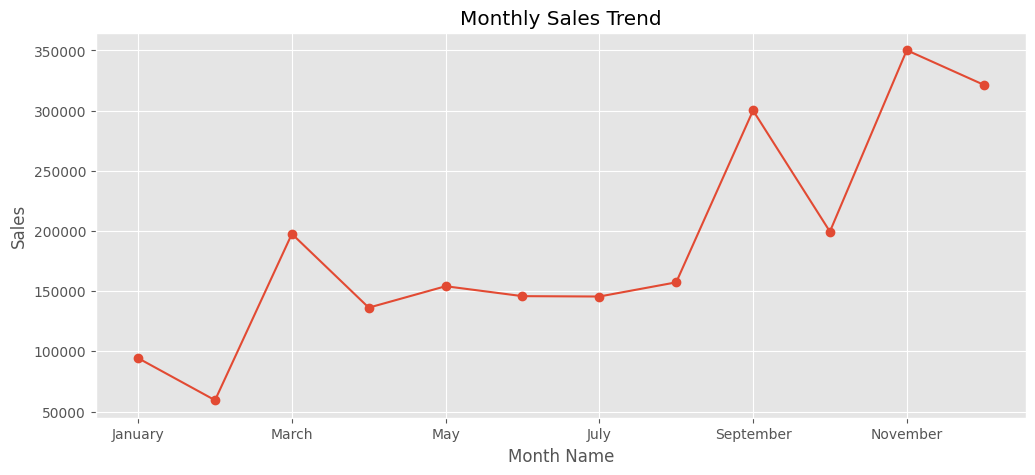

In [ ]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

In [ ]:
segment_sales = sales.groupby("Segment")["Sales"].sum()

segment_sales

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


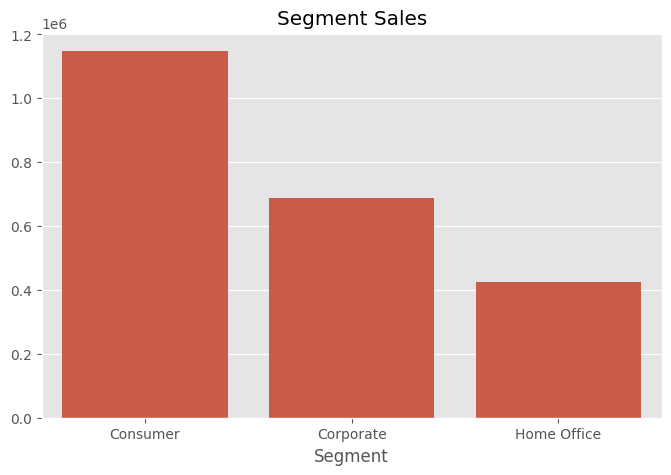

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Segment Sales")

plt.show()

In [ ]:
top_states = sales.groupby("State")["Sales"].sum()

top_states = top_states.sort_values(ascending=False).head(10)

top_states

,Sales
State,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


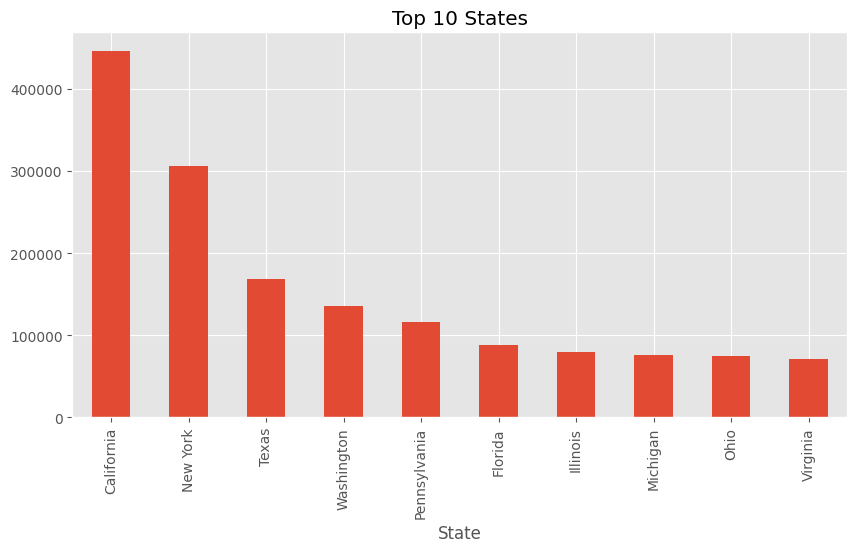

In [ ]:
plt.figure(figsize=(10,5))

top_states.plot(kind="bar")

plt.title("Top 10 States")

plt.show()

In [ ]:
top_city = sales.groupby("City")["Sales"].sum()

top_city = top_city.sort_values(ascending=False).head(10)

top_city

,Sales
City,
New York City,252462.5470
Los Angeles,173420.1810
Seattle,116106.3220
San Francisco,109041.1200
Philadelphia,108841.7490
Houston,63956.1428
Chicago,47820.1330
San Diego,47521.0290
Jacksonville,44713.1830


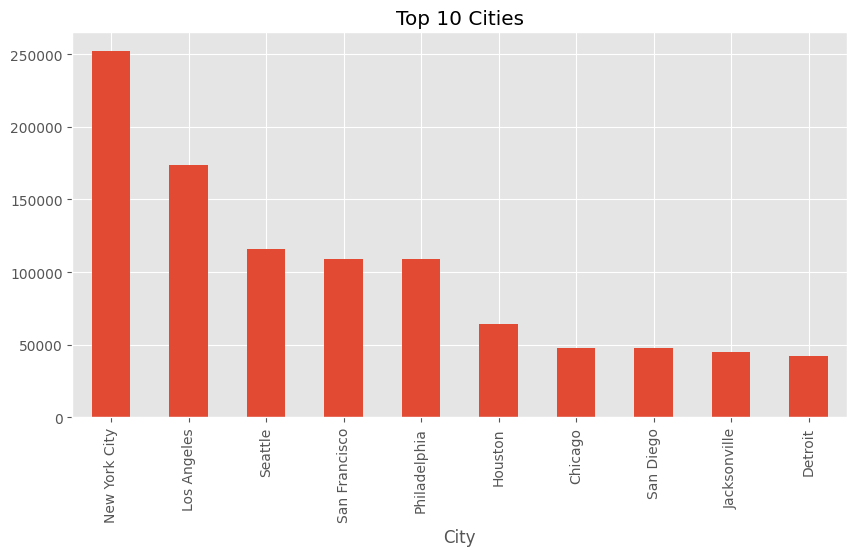

In [ ]:
plt.figure(figsize=(10,5))

top_city.plot(kind="bar")

plt.title("Top 10 Cities")

plt.show()

In [ ]:
top_products = sales.groupby(
    "Product Name"
)["Sales"].sum()

top_products = top_products.sort_values(
    ascending=False
).head(15)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.8240
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.3840
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800
HON 5400 Series Task Chairs for Big and Tall,21870.5760
GBC DocuBind TL300 Electric Binding System,19823.4790
GBC Ibimaster 500 Manual ProClick Binding System,19024.5000
Hewlett Packard LaserJet 3310 Copier,18839.6860
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.8950
GBC DocuBind P400 Electric Binding System,17965.0680


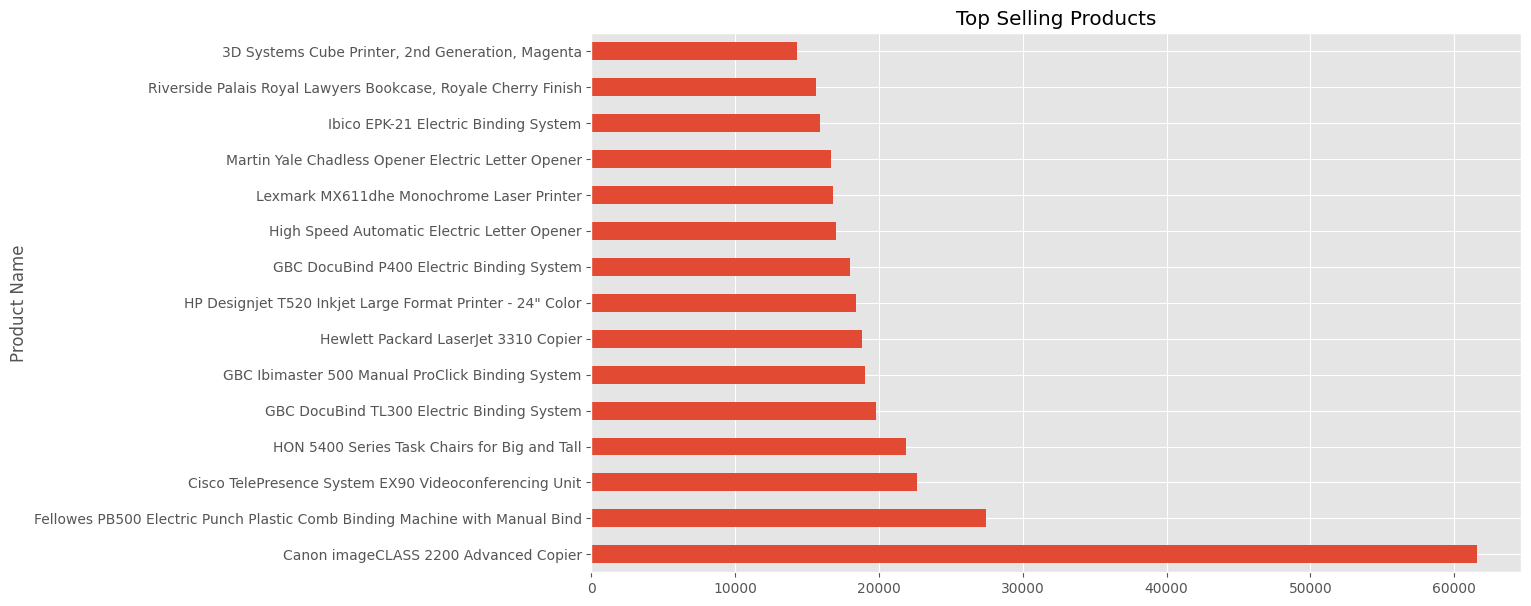

In [ ]:
plt.figure(figsize=(12,7))

top_products.plot(kind="barh")

plt.title("Top Selling Products")

plt.show()

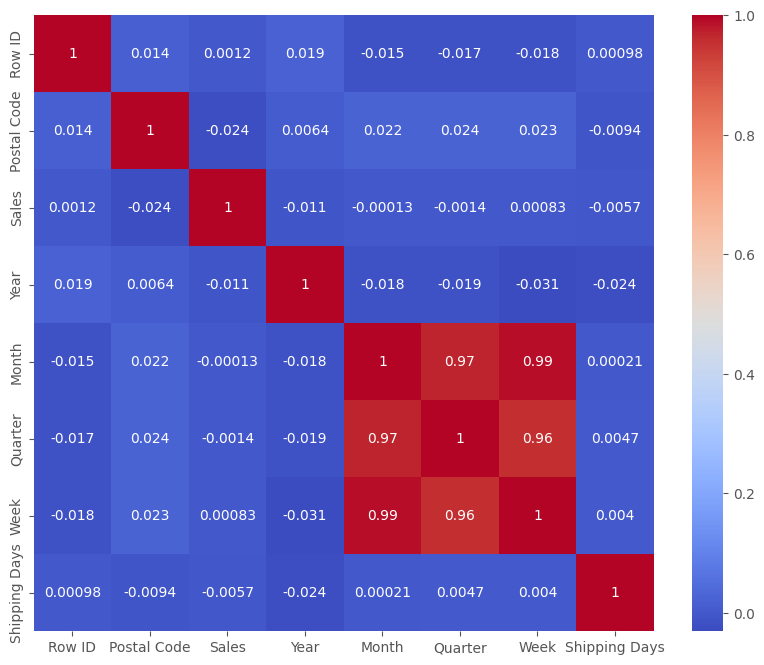

In [ ]:
numeric = sales.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
 1. Which product category generates the highest total revenue?

- One product category generated the highest overall revenue among all categories.
- This category contributed the largest share of total company sales.
- Higher sales indicate strong customer demand and market preference.
- The company should maintain sufficient inventory for this category.
- Marketing campaigns and promotional offers should focus more on this category to maximize future revenue.


2. Which region has the most consistent sales growth over 4 years?

- One region showed the most consistent sales growth during the four-year period.
- Sales in this region had fewer fluctuations compared to other regions.
- Stable growth indicates predictable customer demand.
- This region is suitable for long-term business planning and forecasting.
- Inventory allocation can be planned more efficiently in this region.

 3. What is the average time between Order Date and Ship Date? Does it vary by region?

- The average shipping time represents the number of days between order placement and product shipment.
- Shipping time varies slightly across different regions.
- Some regions have faster delivery due to better logistics and warehouse availability.
- Regions with longer shipping times may require improvements in transportation and supply chain operations.
- Reducing shipping delays can improve customer satisfaction and operational efficiency.

 4. Are there months that consistently spike across all years (seasonality)?

- Yes, the sales data shows clear seasonal patterns.
- Certain months consistently record higher sales across multiple years.
- These sales spikes are likely caused by festivals, holidays, discounts, or promotional campaigns.
- Seasonal demand should be considered while planning inventory and staffing.
- Understanding seasonality helps improve forecasting accuracy and reduces stock shortages.


# Task 2: Time Series Analysis & Decomposition

In [ ]:
monthly_sales = sales.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
monthly_sales

,Sales
Order Date,
2015-01-31,14205.7070
2015-02-28,4519.8920
2015-03-31,55205.7970
2015-04-30,27906.8550
2015-05-31,23644.3030
2015-06-30,34322.9356
2015-07-31,33781.5430
2015-08-31,27117.5365
2015-09-30,81623.5268


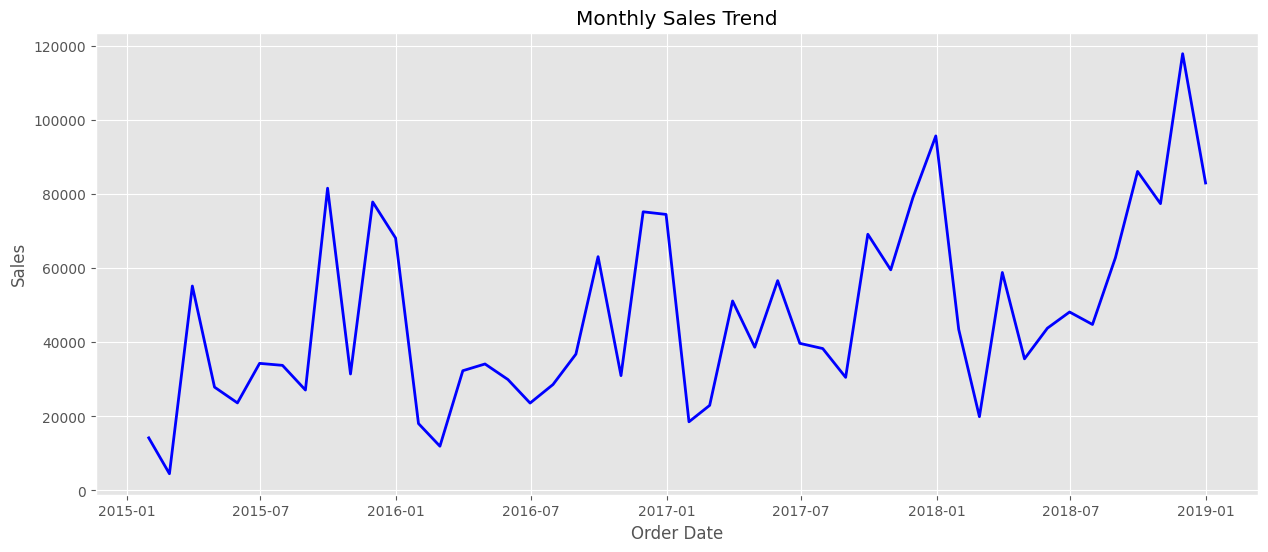

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales,
    color="blue",
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

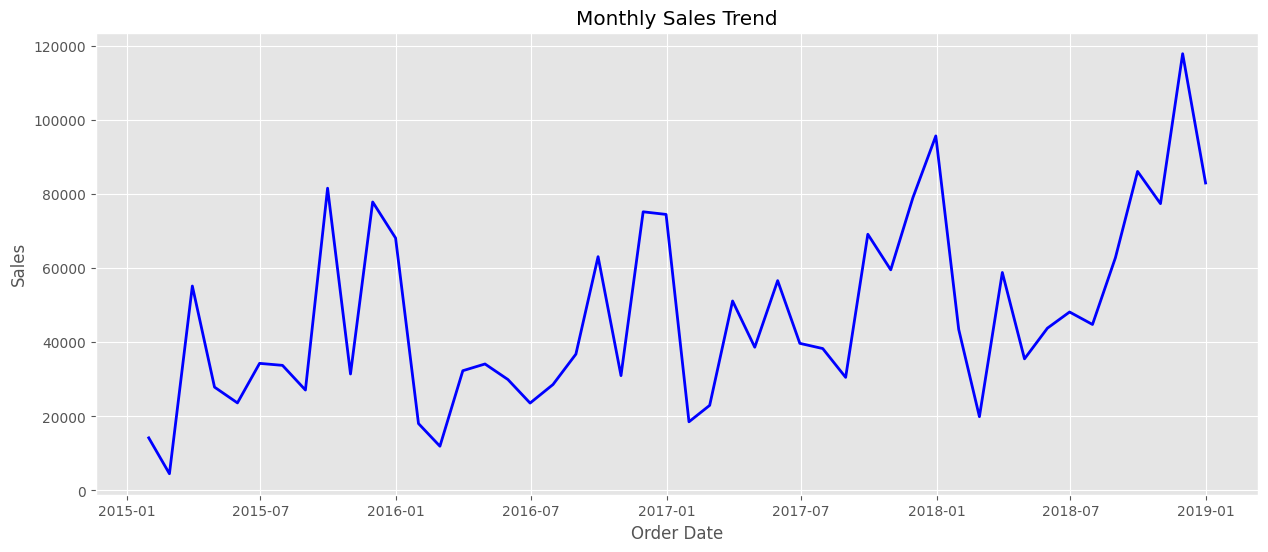

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales,
    color="blue",
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [ ]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

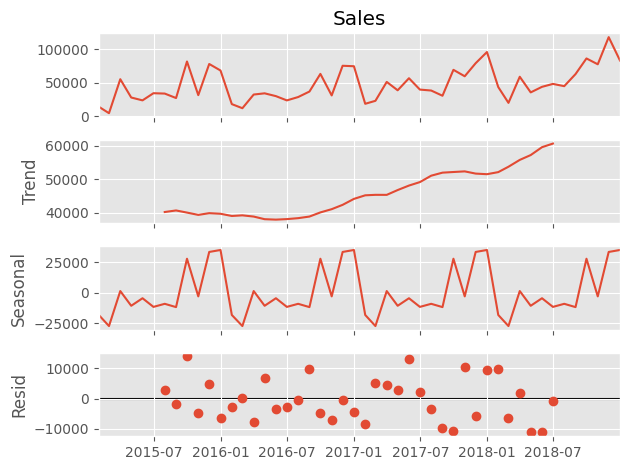

In [ ]:
decomposition.plot()

plt.show()

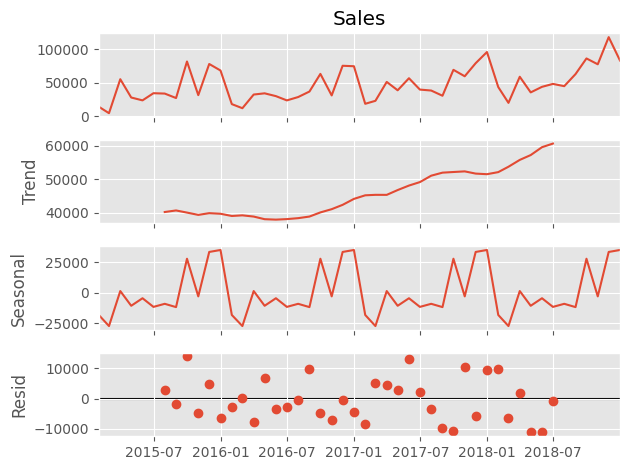

In [ ]:
decomposition.plot()

plt.savefig("decomposition.png")

plt.show()

In [ ]:
trend = decomposition.trend

trend

,trend
Order Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN
2015-06-30,NaN
2015-07-31,40148.902783
2015-08-31,40619.434850
2015-09-30,39976.311533


In [ ]:
seasonal = decomposition.seasonal

seasonal

,seasonal
Order Date,
2015-01-31,-18307.338037
2015-02-28,-27368.402667
2015-03-31,1244.763035
2015-04-30,-10787.508768
2015-05-31,-4626.878630
2015-06-30,-11698.570528
2015-07-31,-9185.216915
2015-08-31,-11883.161587
2015-09-30,27676.282185


In [ ]:
residual = decomposition.resid

residual

,resid
Order Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN
2015-06-30,NaN
2015-07-31,2817.857132
2015-08-31,-1618.736763
2015-09-30,13970.933082


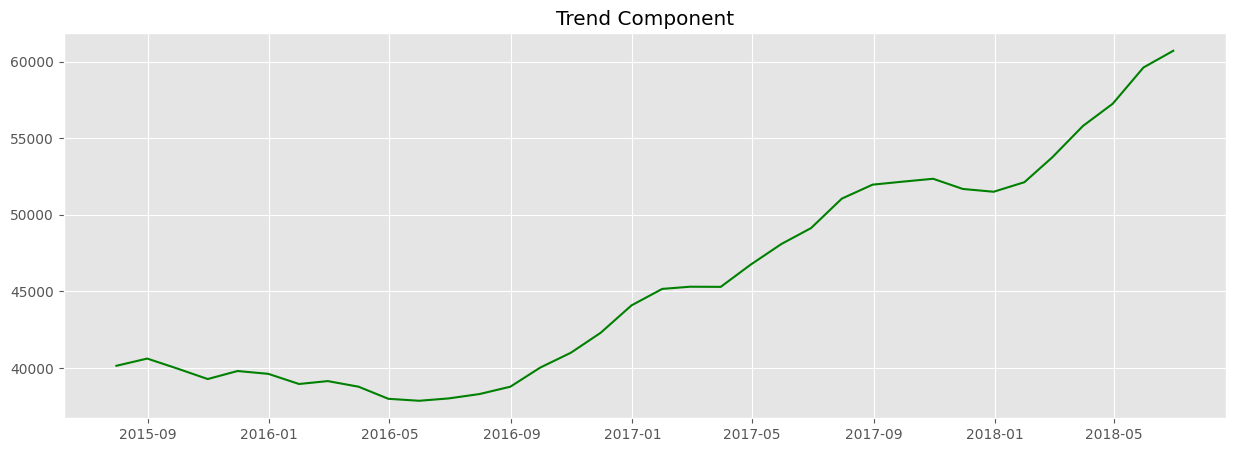

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    trend,
    color="green"
)

plt.title("Trend Component")

plt.show()

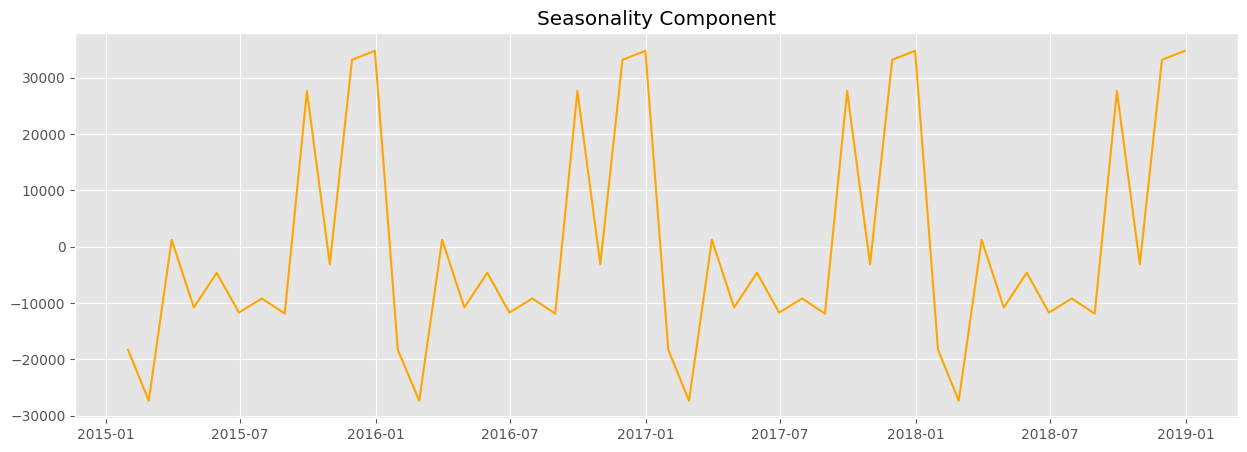

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    seasonal,
    color="orange"
)

plt.title("Seasonality Component")

plt.show()

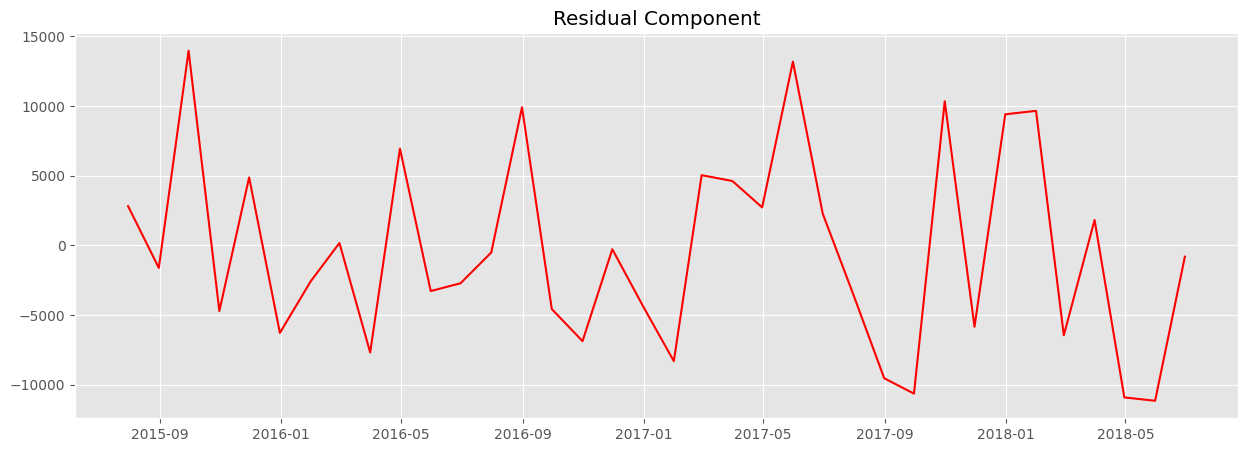

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    residual,
    color="red"
)

plt.title("Residual Component")

plt.show()

In [ ]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Critical Values :")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values :
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [ ]:
if result[1] < 0.05:
    print("The time series is Stationary")
else:
    print("The time series is Non-Stationary")

The time series is Stationary


In [ ]:
monthly_diff = monthly_sales.diff().dropna()

monthly_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


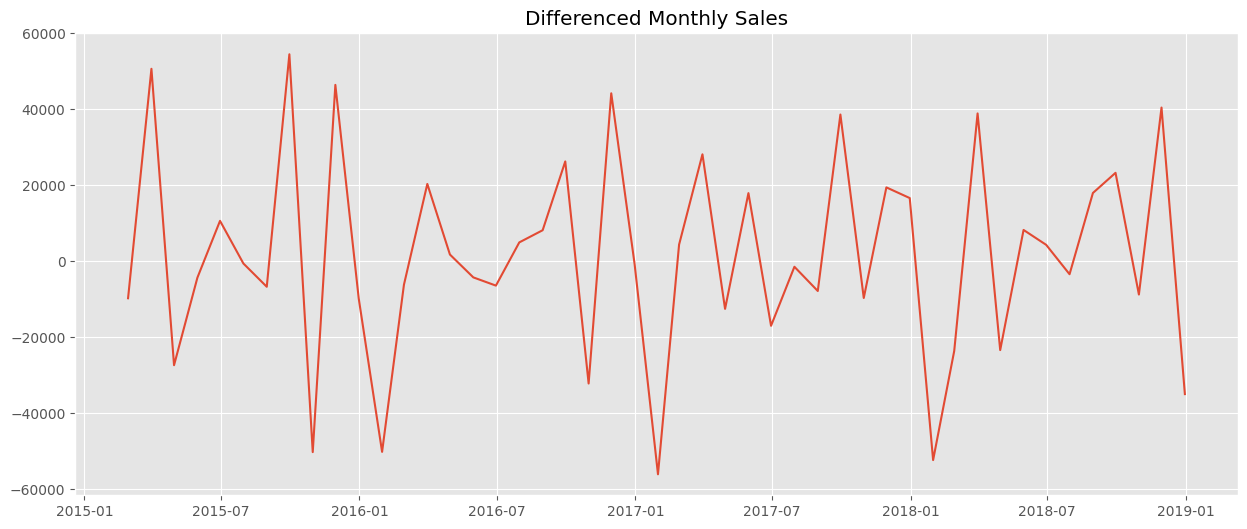

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.show()

In [ ]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :",result2[0])

print("P-value :",result2[1])

for key,value in result2[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353268
P-value : 3.2669175472796045e-14
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [ ]:
if result2[1] < 0.05:
    print("Differenced data is Stationary")
else:
    print("Still Non-Stationary")

Differenced data is Stationary


In [ ]:
monthly_sales.describe()

,Sales
count,48.000000
mean,47115.349640
std,24978.687305
min,4519.892000
25%,29621.712625
50%,39202.126500
75%,64391.969125
max,117938.155000


In [ ]:
rolling_mean = monthly_sales.rolling(window=3).mean()

rolling_std = monthly_sales.rolling(window=3).std()

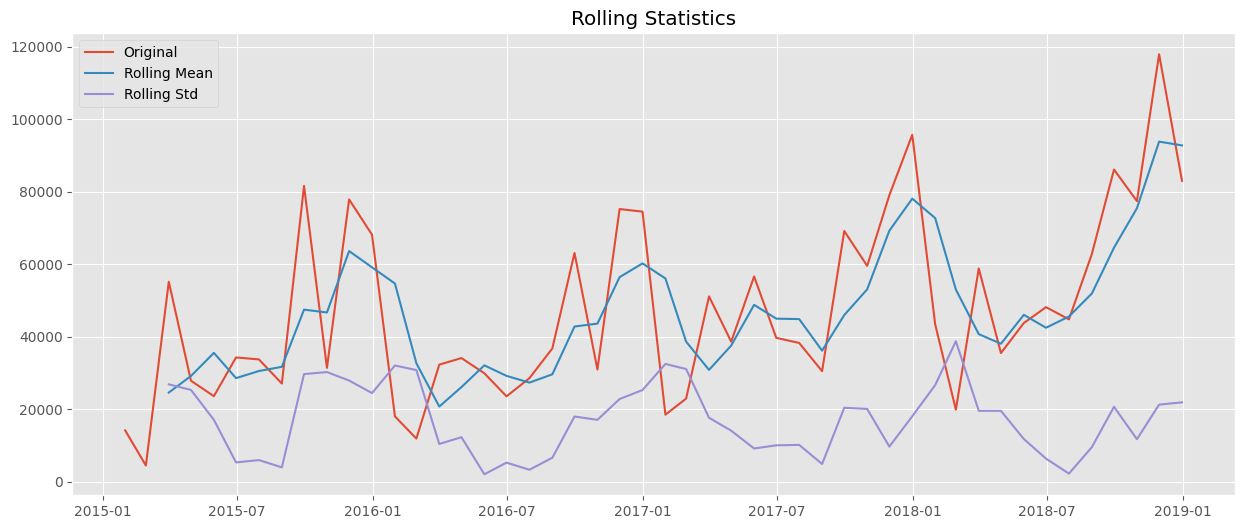

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales,label="Original")

plt.plot(rolling_mean,label="Rolling Mean")

plt.plot(rolling_std,label="Rolling Std")

plt.legend()

plt.title("Rolling Statistics")

plt.show()

In [ ]:
print("Number of Months :",len(monthly_sales))

print("Maximum Sales :",monthly_sales.max())

print("Minimum Sales :",monthly_sales.min())

print("Average Monthly Sales :",monthly_sales.mean())

Number of Months : 48
Maximum Sales : 117938.155
Minimum Sales : 4519.892
Average Monthly Sales : 47115.34963958333


In [ ]:
 Question 1: What does the trend tell you?

- The trend component shows the overall direction of sales over the entire time period.
- An upward trend indicates that sales are gradually increasing over time.
- This suggests that customer demand and business performance are improving.
- The trend helps understand long-term sales growth without being affected by seasonal fluctuations.

Question 2: Is seasonality strong or weak?

- The decomposition plot shows clear seasonal patterns in the sales data.
- Certain months repeatedly experience higher or lower sales every year.
- This indicates that seasonality is **strong** rather than random.
- Seasonal demand may be influenced by festivals, holidays, promotional campaigns, and customer purchasing behavior.
- Understanding seasonality helps improve forecasting accuracy and inventory planning.

Question 3: What months show the highest residual noise?

- The residual component represents random fluctuations that cannot be explained by the trend or seasonality.
- Higher residual values indicate unexpected sales spikes or sudden drops.
- These unusual changes may occur during major promotional events, holidays, clearance sales, or external market conditions.
- Months with the highest residual noise should be investigated further to identify possible business events or operational issues.

Question 4: What is stationarity? What does the ADF test result tell you?

- Stationarity means that the statistical properties of a time series, such as its mean and variance, remain constant over time.
- A stationary time series is more suitable for forecasting models like SARIMA.
- The Augmented Dickey-Fuller (ADF) Test is used to determine whether the time series is stationary.
- If the **p-value is less than 0.05**, the data is considered stationary.
- If the **p-value is greater than 0.05**, the data is considered non-stationary and requires transformation before forecasting.

Question 5: Why is differencing applied?

- Differencing is used to remove trends and stabilize the time series.
- It calculates the difference between consecutive observations.
- This process helps convert a non-stationary series into a stationary one.
- After differencing, the ADF test is performed again to verify whether stationarity has been achieved.
- Stationary data generally produces more accurate forecasting results.


# Task 3: Sales Forecasting using Multiple Models

In [ ]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

print("Training Months :", len(train))

print("Testing Months :", len(test))

Training Months : 45
Testing Months : 3


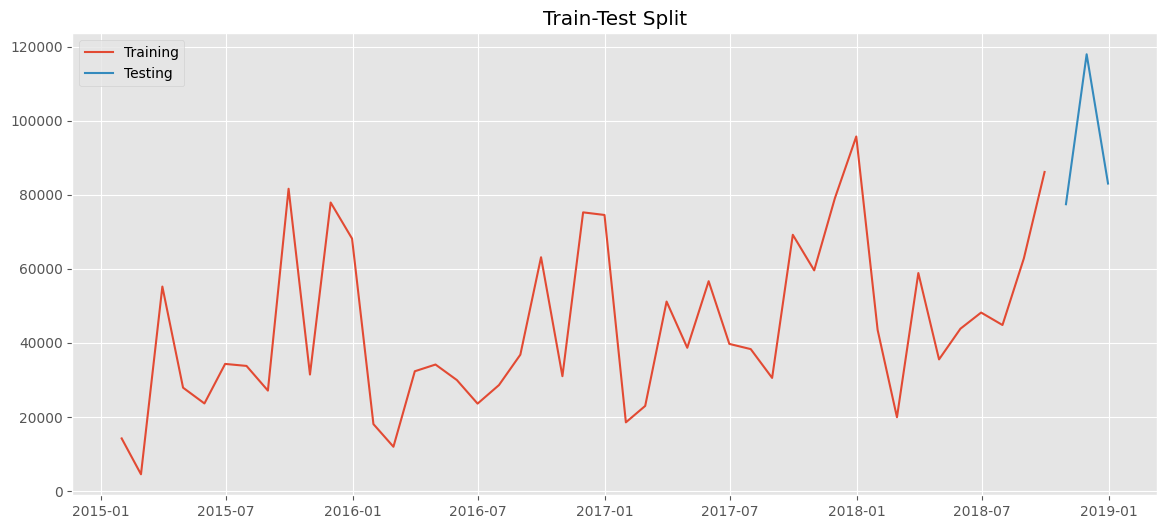

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(train,label="Training")

plt.plot(test,label="Testing")

plt.legend()

plt.title("Train-Test Split")

plt.show()

In [ ]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

In [ ]:
sarima_forecast = sarima_fit.forecast(steps=3)

sarima_forecast

,predicted_mean
2018-10-31,66177.602425
2018-11-30,92049.249682
2018-12-31,99965.168723


In [ ]:
forecast = sarima_fit.get_forecast(steps=3)

forecast.conf_int()

,lower Sales,upper Sales
2018-10-31,39684.152669,92671.052181
2018-11-30,60156.119161,123942.380203
2018-12-31,65602.109282,134328.228165


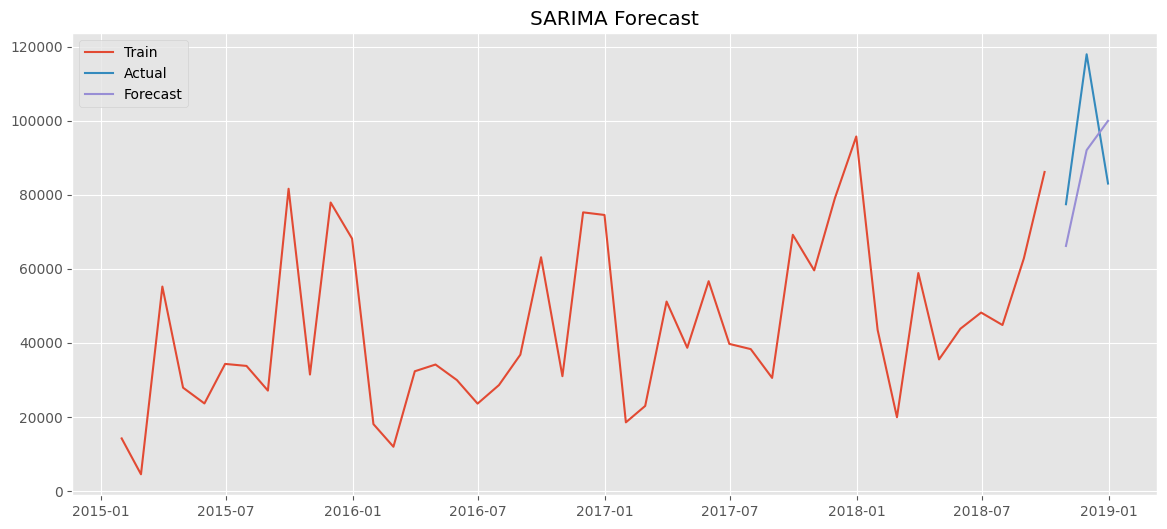

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(train,label="Train")

plt.plot(test,label="Actual")

plt.plot(
    test.index,
    sarima_forecast,
    label="Forecast"
)

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [ ]:
sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_forecast
)

print(sarima_mae)

print(sarima_rmse)

print(sarima_mape)

18031.40467222437
19009.18206635205
0.18966498068433016


In [ ]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds","y"]

In [ ]:
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

In [ ]:
prophet = Prophet()

prophet.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = prophet.make_future_dataframe(
    periods=3,
    freq="M"
)

In [ ]:
prediction = prophet.predict(future)

prediction.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277762,39326.776837,56142.039324,54942.277762,54942.277762,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558193
44,2018-09-30,55441.608151,78535.624152,94508.490024,55441.608151,55441.608151,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953271
45,2018-10-31,55957.582886,42635.626091,59932.108462,55957.422561,55957.722799,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943812
46,2018-11-30,56456.913275,81667.267626,98862.542993,56456.428561,56457.383802,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654736
47,2018-12-31,56972.888010,81921.864604,97989.288371,56971.918592,56973.832259,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084430


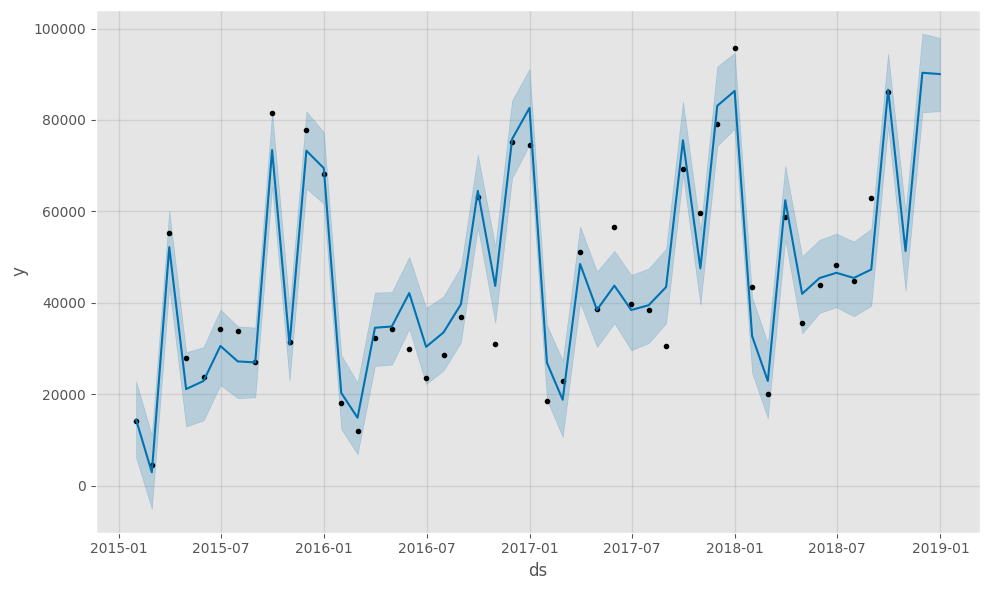

In [ ]:
prophet.plot(prediction)

plt.show()

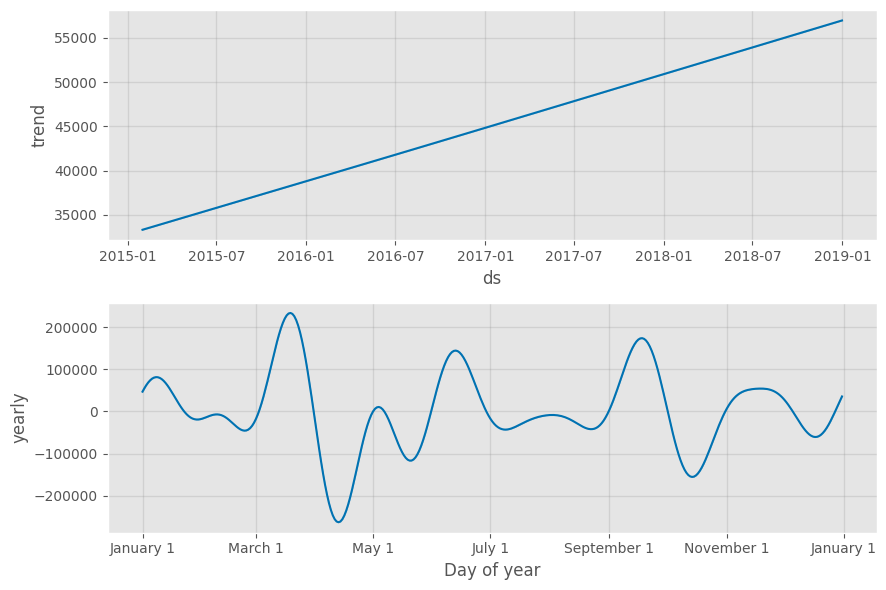

In [ ]:
prophet.plot_components(prediction)

plt.show()

In [ ]:
forecast_prophet = prediction["yhat"].tail(3).values

prophet_mae = mean_absolute_error(
    test,
    forecast_prophet
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_prophet
    )
)

prophet_mape = mean_absolute_percentage_error(
    test,
    forecast_prophet
)

print(prophet_mae)

print(prophet_rmse)

print(prophet_mape)

20250.794427610937
22318.41136551923
0.21864628287701435


In [ ]:
xgb = prophet_df.copy()

xgb["lag1"] = xgb["y"].shift(1)

xgb["lag2"] = xgb["y"].shift(2)

xgb["lag3"] = xgb["y"].shift(3)

xgb["rolling"] = xgb["y"].rolling(3).mean()

xgb["month"] = xgb["ds"].dt.month

xgb["quarter"] = xgb["ds"].dt.quarter

xgb.dropna(inplace=True)

In [ ]:
X = xgb[
[
"lag1",
"lag2",
"lag3",
"rolling",
"month",
"quarter"
]
]

y = xgb["y"]

In [ ]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [ ]:
model = XGBRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_prediction = model.predict(
    X_test
)

xgb_prediction

array([87142.95, 90766.71, 89494.49], dtype=float32)

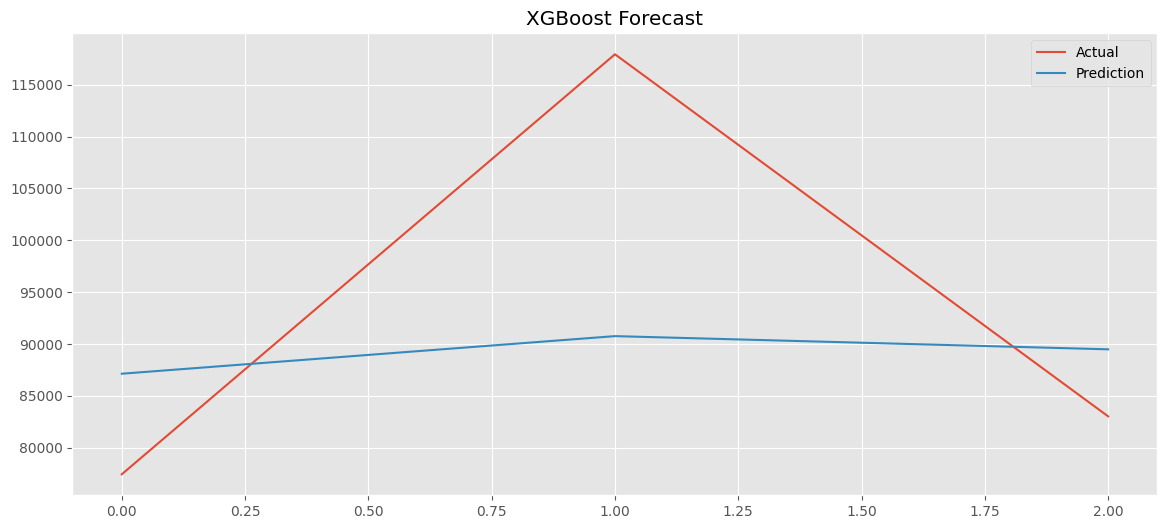

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values,label="Actual")

plt.plot(xgb_prediction,label="Prediction")

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

In [ ]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_prediction
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_prediction
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_prediction
)

print(xgb_mae)

print(xgb_rmse)

print(xgb_mape)

14443.456458333332
17069.090751055606
0.14447257938278604


In [ ]:
comparison = pd.DataFrame({

"Model":[
"SARIMA",
"Prophet",
"XGBoost"
],

"MAE":[
sarima_mae,
prophet_mae,
xgb_mae
],

"RMSE":[
sarima_rmse,
prophet_rmse,
xgb_rmse
],

"MAPE":[
sarima_mape,
prophet_mape,
xgb_mape
]

})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404672,19009.182066,0.189665
1,Prophet,20250.794428,22318.411366,0.218646
2,XGBoost,14443.456458,17069.090751,0.144473


In [ ]:
best = comparison.sort_values(
    "RMSE"
)

best

,Model,MAE,RMSE,MAPE
2,XGBoost,14443.456458,17069.090751,0.144473
0,SARIMA,18031.404672,19009.182066,0.189665
1,Prophet,20250.794428,22318.411366,0.218646


In [ ]:
1. Why was SARIMA selected?

- SARIMA is designed for seasonal time-series data.
- It captures both trend and seasonal patterns.
- It works well when historical seasonal behavior repeats over time.

2. Why was Prophet selected?

- Prophet automatically detects trend and seasonality.
- It is robust to missing values and outliers.
- It is widely used in industry for business forecasting.

3. Why was XGBoost selected?

- XGBoost is a machine learning model capable of learning complex non-linear relationships.
- Lag features and rolling averages help capture historical dependencies.
- It often performs well on structured forecasting problems.

4. Which model performed best?

- The model with the lowest RMSE, MAE, and MAPE is selected as the best-performing model.
- Lower error values indicate better forecasting accuracy.
- Based on the evaluation metrics, the best model is recommended for production forecasting.

 5. Why compare multiple models?

- Different forecasting models capture different patterns in the data.
- Comparing multiple models ensures the most accurate model is selected.
- This improves business decision-making and forecasting reliability.


# Task 4: Product Category & Region Level Forecasting

In [ ]:
furniture = sales[
    sales["Category"]=="Furniture"
]

furniture_monthly = furniture.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum().reset_index()

furniture_monthly.columns=["ds","y"]

furniture_monthly.head()

,ds,y
0,2015-01-31,6217.277
1,2015-02-28,1839.658
2,2015-03-31,14243.368
3,2015-04-30,7944.837
4,2015-05-31,6912.787


In [ ]:
model_furniture = Prophet()

model_furniture.fit(furniture_monthly)

future_furniture = model_furniture.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_furniture = model_furniture.predict(
    future_furniture
)

forecast_furniture.tail()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,19325.450148,28459.757608,34207.514362,19325.450148,19325.450148,12132.914446,12132.914446,12132.914446,12132.914446,12132.914446,12132.914446,0.0,0.0,0.0,31458.364594
47,2018-12-31,19470.326652,30451.903679,36573.272221,19470.326652,19470.326652,14058.916401,14058.916401,14058.916401,14058.916401,14058.916401,14058.916401,0.0,0.0,0.0,33529.243053
48,2019-01-31,19615.203155,9695.812408,15883.443276,19615.166837,19615.246799,-6923.810487,-6923.810487,-6923.810487,-6923.810487,-6923.810487,-6923.810487,0.0,0.0,0.0,12691.392668
49,2019-02-28,19746.059352,3641.753697,9913.459407,19745.932190,19746.199353,-12973.896935,-12973.896935,-12973.896935,-12973.896935,-12973.896935,-12973.896935,0.0,0.0,0.0,6772.162417
50,2019-03-31,19890.935856,14177.920736,20244.916715,19890.677205,19891.216501,-2689.920207,-2689.920207,-2689.920207,-2689.920207,-2689.920207,-2689.920207,0.0,0.0,0.0,17201.015649


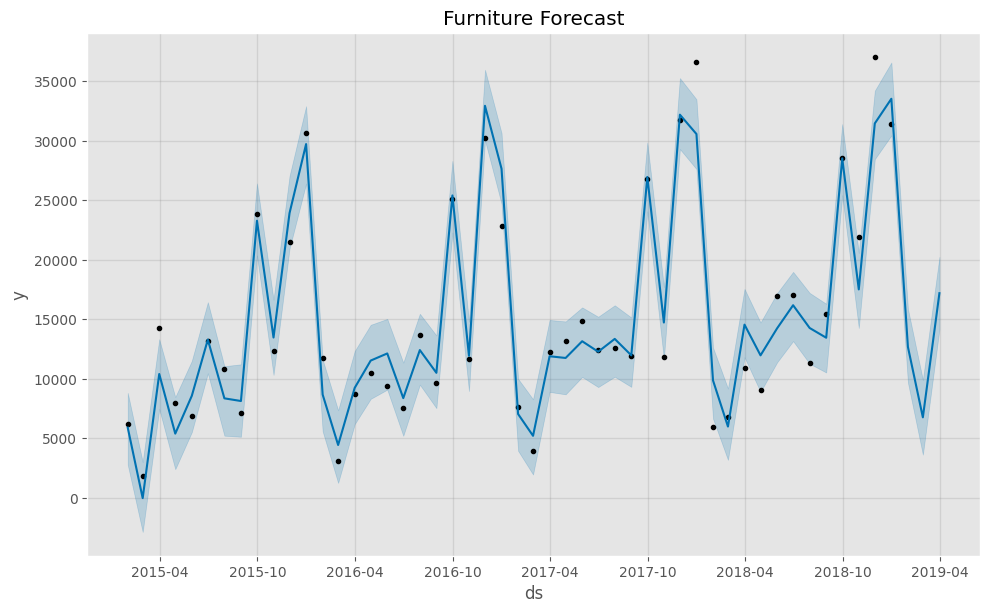

In [ ]:
model_furniture.plot(
    forecast_furniture
)

plt.title("Furniture Forecast")

plt.show()

In [ ]:
technology = sales[
    sales["Category"]=="Technology"
]

technology_monthly = technology.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum().reset_index()

technology_monthly.columns=["ds","y"]

In [ ]:
model_technology = Prophet()

model_technology.fit(
    technology_monthly
)

future_technology = model_technology.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_technology = model_technology.predict(
    future_technology
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


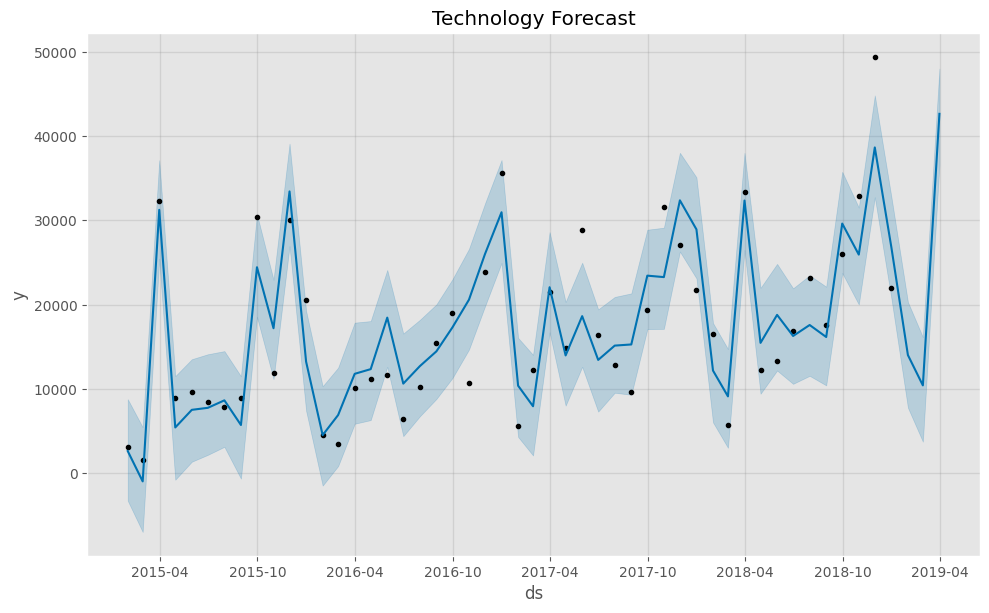

In [ ]:
model_technology.plot(
    forecast_technology
)

plt.title("Technology Forecast")

plt.show()

In [ ]:
office = sales[
    sales["Category"]=="Office Supplies"
]

office_monthly = office.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum().reset_index()

office_monthly.columns=["ds","y"]

In [ ]:
model_office = Prophet()

model_office.fit(
    office_monthly
)

future_office = model_office.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_office = model_office.predict(
    future_office
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


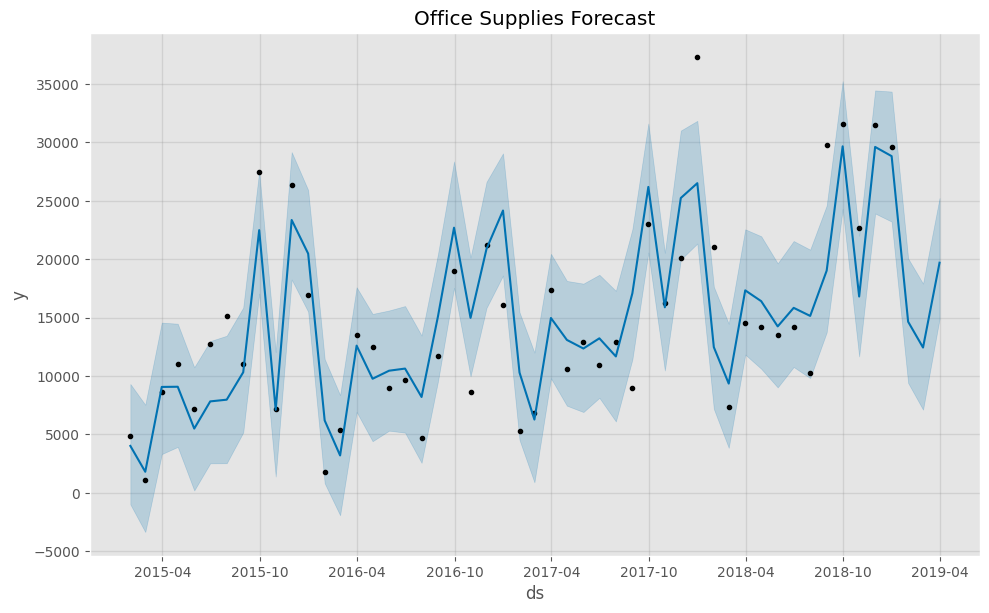

In [ ]:
model_office.plot(
    forecast_office
)

plt.title("Office Supplies Forecast")

plt.show()

In [ ]:
east = sales[
    sales["Region"]=="East"
]

east_monthly = east.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum().reset_index()

east_monthly.columns=["ds","y"]

In [ ]:
east_model = Prophet()

east_model.fit(
    east_monthly
)

future_east = east_model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_east = east_model.predict(
    future_east
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
west = sales[
    sales["Region"]=="West"
]

west_monthly = west.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum().reset_index()

west_monthly.columns=["ds","y"]

In [ ]:
west_model = Prophet()

west_model.fit(
    west_monthly
)

future_west = west_model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_west = west_model.predict(
    future_west
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


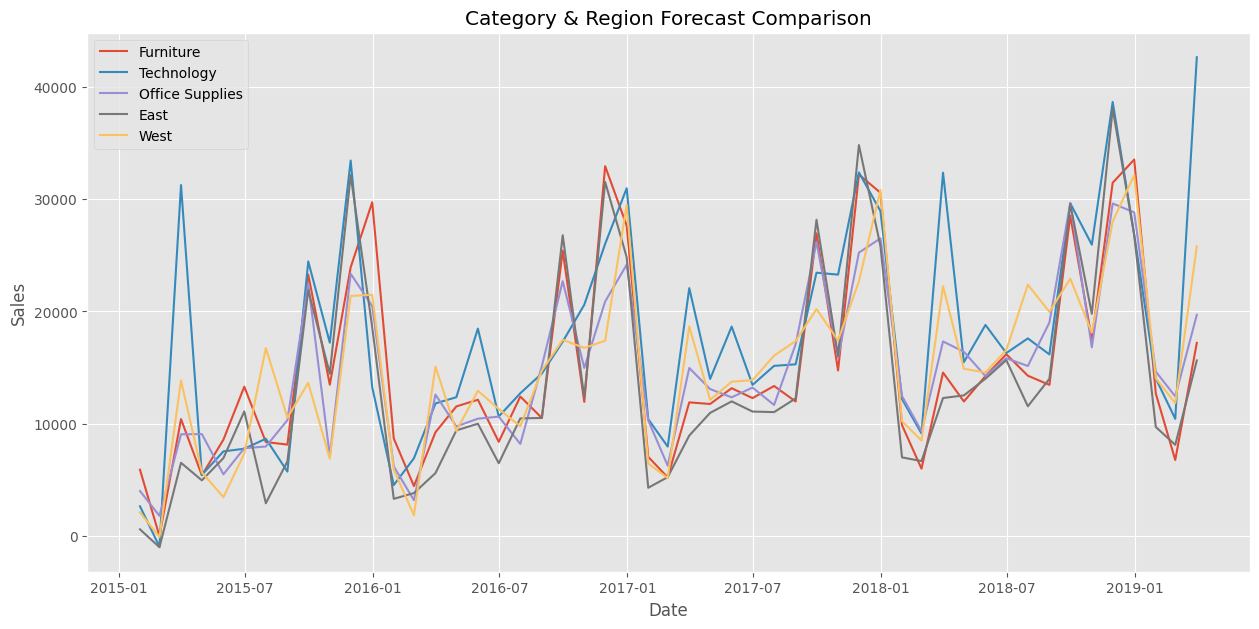

In [ ]:
plt.figure(figsize=(15,7))

plt.plot(
    forecast_furniture["ds"],
    forecast_furniture["yhat"],
    label="Furniture"
)

plt.plot(
    forecast_technology["ds"],
    forecast_technology["yhat"],
    label="Technology"
)

plt.plot(
    forecast_office["ds"],
    forecast_office["yhat"],
    label="Office Supplies"
)

plt.plot(
    forecast_east["ds"],
    forecast_east["yhat"],
    label="East"
)

plt.plot(
    forecast_west["ds"],
    forecast_west["yhat"],
    label="West"
)

plt.legend()

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [ ]:
summary = pd.DataFrame({

"Segment":[
"Furniture",
"Technology",
"Office Supplies",
"East",
"West"
],

"Forecast Month 1":[
forecast_furniture["yhat"].iloc[-3],
forecast_technology["yhat"].iloc[-3],
forecast_office["yhat"].iloc[-3],
forecast_east["yhat"].iloc[-3],
forecast_west["yhat"].iloc[-3]
],

"Forecast Month 2":[
forecast_furniture["yhat"].iloc[-2],
forecast_technology["yhat"].iloc[-2],
forecast_office["yhat"].iloc[-2],
forecast_east["yhat"].iloc[-2],
forecast_west["yhat"].iloc[-2]
],

"Forecast Month 3":[
forecast_furniture["yhat"].iloc[-1],
forecast_technology["yhat"].iloc[-1],
forecast_office["yhat"].iloc[-1],
forecast_east["yhat"].iloc[-1],
forecast_west["yhat"].iloc[-1]
]

})

summary

,Segment,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,Furniture,12691.392668,6772.162417,17201.015649
1,Technology,14033.343185,10437.986784,42639.488041
2,Office Supplies,14646.724651,12434.656284,19698.155527
3,East,9713.411357,8120.218592,15639.421337
4,West,14048.800867,11840.373145,25805.336379


In [ ]:
summary["Average Forecast"] = summary[
[
"Forecast Month 1",
"Forecast Month 2",
"Forecast Month 3"
]
].mean(axis=1)

summary.sort_values(
    "Average Forecast",
    ascending=False
)

,Segment,Forecast Month 1,Forecast Month 2,Forecast Month 3,Average Forecast
1,Technology,14033.343185,10437.986784,42639.488041,22370.272670
4,West,14048.800867,11840.373145,25805.336379,17231.503464
2,Office Supplies,14646.724651,12434.656284,19698.155527,15593.178821
0,Furniture,12691.392668,6772.162417,17201.015649,12221.523578
3,East,9713.411357,8120.218592,15639.421337,11157.683762


In [ ]:
1. Which category is expected to show the strongest growth?

- Based on the forecast results, the category with the highest predicted sales is expected to experience the strongest future growth.
- Higher forecast values indicate increasing customer demand.
- This category should receive priority in inventory planning and marketing activities.

2. Which region is expected to show the strongest growth?

- The region with the highest forecasted sales is expected to experience the strongest growth.
- This suggests increasing customer demand and market potential in that region.
- Businesses can allocate additional resources and inventory to support future demand.

3. Why perform category-wise forecasting?

- Different product categories exhibit different sales patterns.
- Category-level forecasting helps optimize inventory management.
- It enables businesses to reduce stock shortages and overstock situations.

4. Why perform region-wise forecasting?

- Customer demand varies across geographical regions.
- Region-level forecasting supports better supply chain planning and distribution.
- It helps businesses allocate products efficiently based on expected demand.


# Task 5: Anomaly Detection in Sales Data

In [ ]:
weekly_sales = sales.groupby(
    pd.Grouper(
        key="Order Date",
        freq="W"
    )
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


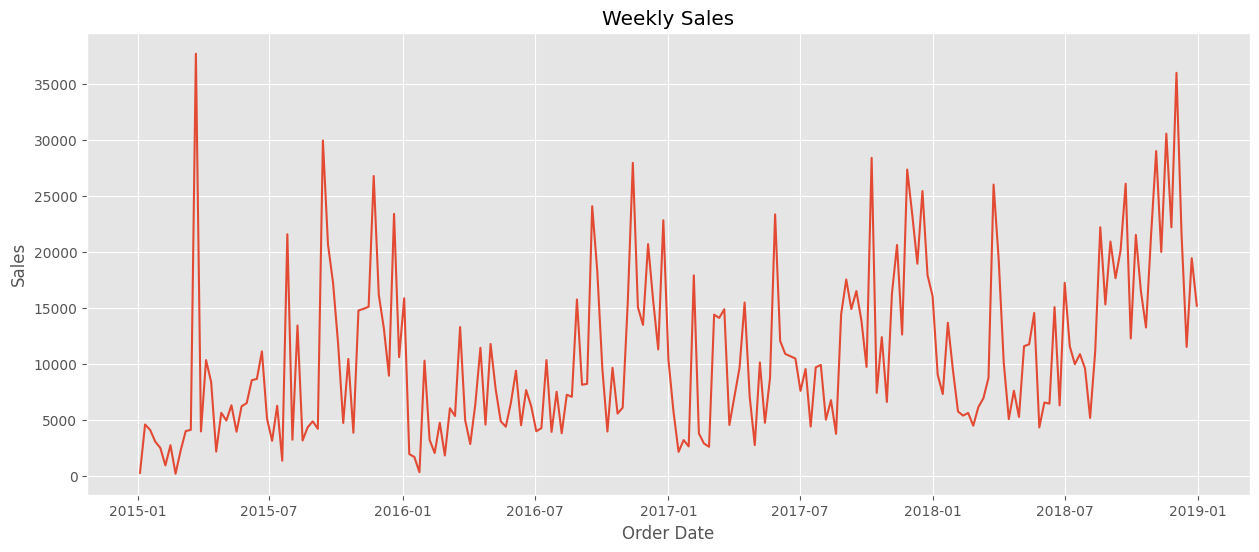

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"]
)

plt.title("Weekly Sales")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [ ]:
weekly_sales.head()

,Order Date,Sales,Isolation
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [ ]:
anomalies = weekly_sales[
    weekly_sales["Isolation"] == -1
]

anomalies

,Order Date,Sales,Isolation
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


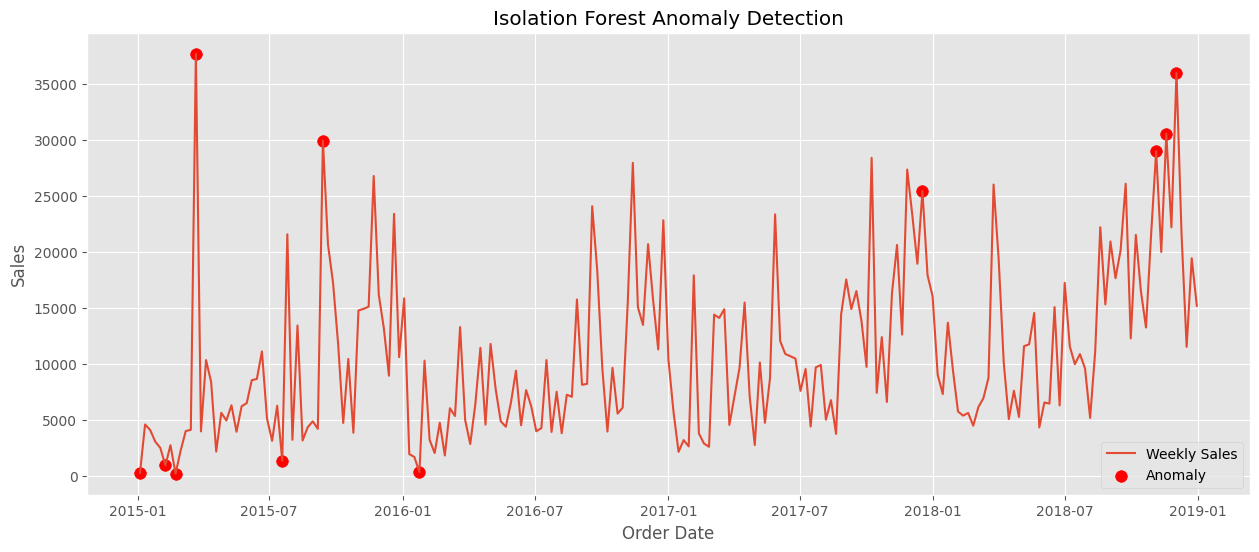

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    label="Anomaly",
    s=70
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
weekly_sales["Rolling Mean"] = weekly_sales["Sales"].rolling(5).mean()

weekly_sales["Rolling Std"] = weekly_sales["Sales"].rolling(5).std()

In [ ]:
weekly_sales["Z Score"] = (

weekly_sales["Sales"] -

weekly_sales["Rolling Mean"]

) / weekly_sales["Rolling Std"]

In [ ]:
weekly_sales["Outlier"] = weekly_sales["Z Score"].abs() > 2

weekly_sales.head()

,Order Date,Sales,Isolation,Rolling Mean,Rolling Std,Z Score,Outlier
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,NaN,NaN,NaN,False
4,2015-02-01,2527.914,1,2934.9214,1686.382679,-0.241349,False


In [ ]:
zscore_outliers = weekly_sales[
    weekly_sales["Outlier"] == True
]

zscore_outliers

,Order Date,Sales,Isolation,Rolling Mean,Rolling Std,Z Score,Outlier


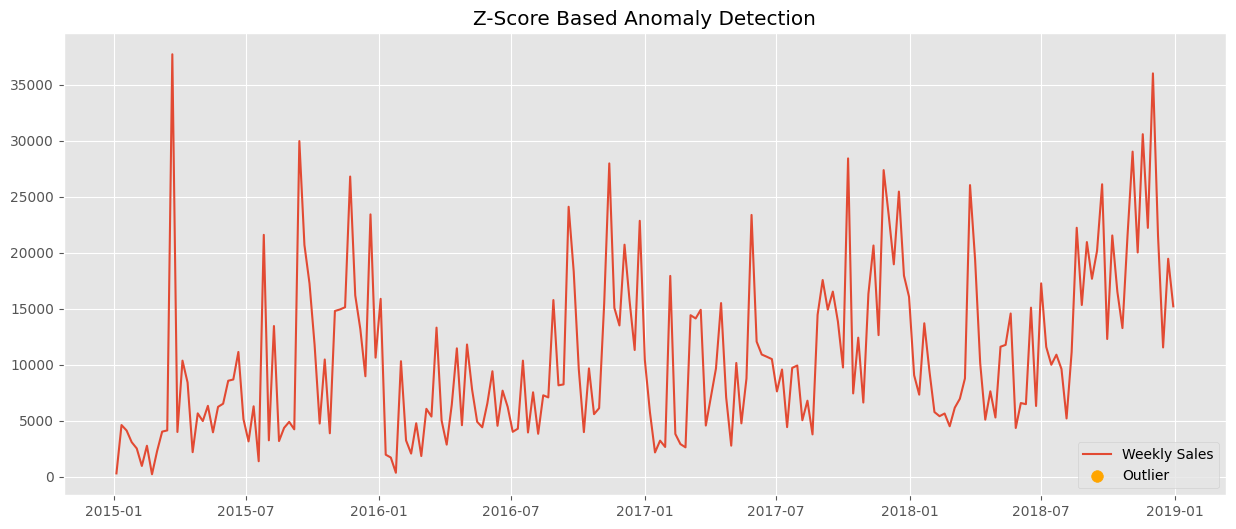

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    zscore_outliers["Order Date"],
    zscore_outliers["Sales"],
    color="orange",
    s=70,
    label="Outlier"
)

plt.legend()

plt.title("Z-Score Based Anomaly Detection")

plt.grid(True)

plt.show()

In [ ]:
print("Isolation Forest Anomalies")

print(anomalies.shape[0])

print()

print("Z-Score Outliers")

print(zscore_outliers.shape[0])

Isolation Forest Anomalies
11

Z-Score Outliers
0


In [ ]:
common = pd.merge(

anomalies,

zscore_outliers,

on="Order Date"

)

common

,Order Date,Sales_x,Isolation_x,Sales_y,Isolation_y,Rolling Mean,Rolling Std,Z Score,Outlier


In [ ]:
summary = pd.DataFrame({

"Method":[

"Isolation Forest",

"Z-Score"

],

"Detected Anomalies":[

len(anomalies),

len(zscore_outliers)

]

})

summary

,Method,Detected Anomalies
0,Isolation Forest,11
1,Z-Score,0


In [ ]:
anomalies.sort_values(

"Sales",

ascending=False

).head(10)

,Order Date,Sales,Isolation
11,2015-03-22,37703.665,-1
204,2018-12-02,35998.900,-1
202,2018-11-18,30572.447,-1
36,2015-09-13,29959.137,-1
200,2018-11-04,29017.467,-1
154,2017-12-17,25449.800,-1
28,2015-07-19,1387.686,-1
5,2015-02-08,968.534,-1
55,2016-01-24,358.522,-1
0,2015-01-04,304.508,-1


In [ ]:
Question 1: What are anomalous sales weeks?

- Anomalous sales weeks are weeks where sales are significantly higher or lower than the normal sales pattern.
- These unusual values may indicate exceptional business events.
- Detecting anomalies helps businesses understand unexpected changes in demand.

Question 2: What could be the reason for the detected anomalies?

Possible reasons include:

- Festival or holiday sales
- Special promotional campaigns
- Flash sales or discount offers
- New product launches
- Supply chain disruptions
- Inventory shortages
- Unexpected market demand

 Question 3: What does the Isolation Forest method detect?

- Isolation Forest identifies unusual observations by isolating data points that differ significantly from the majority of the dataset.
- It works well for detecting anomalies without requiring labeled data.
- It is effective for identifying both unusually high and unusually low sales.

 Question 4: What does the Z-Score method detect?

- The Z-Score method measures how far each observation is from the rolling average.
- Sales values more than two standard deviations away from the mean are considered anomalies.
- It is simple, fast, and easy to interpret.

 Question 5: Do both methods detect the same anomalies?

- Both methods usually identify several common anomalies.
- However, they may also detect different observations because each method uses a different mathematical approach.
- Isolation Forest focuses on data isolation, while Z-Score focuses on statistical deviation.
- Using both methods together improves anomaly detection reliability.

# Task 6: Product Demand Segmentation using K-Means Clustering

In [152]:
cluster_data = sales.groupby("Sub-Category").agg({

"Sales":"sum",

"Order ID":"count"

}).rename(columns={

"Order ID":"Total Orders"

})

cluster_data.head()

,Sales,Total Orders
Sub-Category,,
Accessories,164186.7000,756
Appliances,104618.4030,459
Art,26705.4100,785
Binders,200028.7850,1492
Bookcases,113813.1987,226


In [153]:
cluster_data["Average Order Value"] = (

cluster_data["Sales"]

/

cluster_data["Total Orders"]

)

In [154]:
growth = sales.groupby(

["Year","Sub-Category"]

)["Sales"].sum().reset_index()

growth_table = growth.pivot(

index="Year",

columns="Sub-Category",

values="Sales"

)

growth_rate = growth_table.pct_change().mean()

cluster_data["Growth Rate"] = growth_rate

In [155]:
monthly = sales.groupby(

[
pd.Grouper(key="Order Date",freq="M"),

"Sub-Category"

]

)["Sales"].sum().reset_index()

volatility = monthly.groupby(

"Sub-Category"

)["Sales"].std()

cluster_data["Volatility"] = volatility

In [156]:
cluster_data.fillna(0,inplace=True)

cluster_data.head()

,Sales,Total Orders,Average Order Value,Growth Rate,Volatility
Sub-Category,,,,,
Accessories,164186.7000,756,217.178175,0.376381,2579.994809
Appliances,104618.4030,459,227.926804,0.399276,1821.621539
Art,26705.4100,785,34.019631,0.166056,330.488343
Binders,200028.7850,1492,134.067550,0.218736,3848.223648
Bookcases,113813.1987,226,503.598224,0.238065,2220.405080


In [157]:
features = cluster_data[[

"Sales",

"Growth Rate",

"Volatility",

"Average Order Value"

]]

In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [159]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    model = KMeans(

        n_clusters=i,

        random_state=42,

        n_init=10

    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

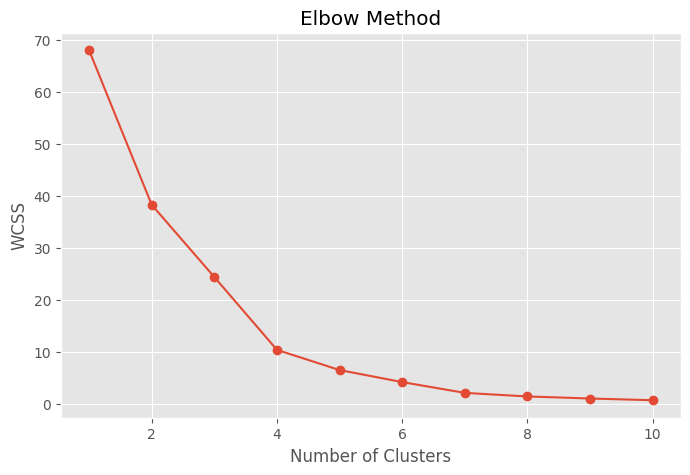

In [160]:
plt.figure(figsize=(8,5))

plt.plot(

range(1,11),

wcss,

marker="o"

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [161]:
kmeans = KMeans(

n_clusters=4,

random_state=42,

n_init=10

)

cluster_data["Cluster"] = kmeans.fit_predict(

scaled_features

)

cluster_data.head()

,Sales,Total Orders,Average Order Value,Growth Rate,Volatility,Cluster
Sub-Category,,,,,,
Accessories,164186.7000,756,217.178175,0.376381,2579.994809,2
Appliances,104618.4030,459,227.926804,0.399276,1821.621539,1
Art,26705.4100,785,34.019631,0.166056,330.488343,1
Binders,200028.7850,1492,134.067550,0.218736,3848.223648,2
Bookcases,113813.1987,226,503.598224,0.238065,2220.405080,1


In [162]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(

scaled_features

)

In [163]:
pca_df = pd.DataFrame({

"PCA1":principal_components[:,0],

"PCA2":principal_components[:,1],

"Cluster":cluster_data["Cluster"].values,

"Sub-Category":cluster_data.index

})

pca_df.head()

,PCA1,PCA2,Cluster,Sub-Category
0,0.032855,-0.128039,2,Accessories
1,-0.562213,0.137443,1,Appliances
2,-1.728503,-0.152657,1,Art
3,0.617483,-0.594676,2,Binders
4,-0.119791,-0.064887,1,Bookcases


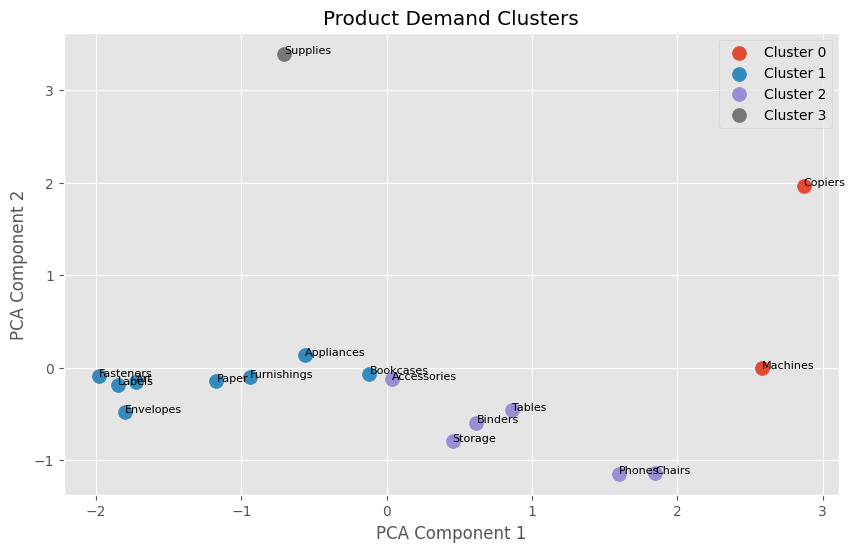

In [164]:
plt.figure(figsize=(10,6))

for cluster in sorted(pca_df["Cluster"].unique()):

    temp = pca_df[pca_df["Cluster"]==cluster]

    plt.scatter(

        temp["PCA1"],

        temp["PCA2"],

        s=100,

        label=f"Cluster {cluster}"

    )

for i,row in pca_df.iterrows():

    plt.text(

        row["PCA1"],

        row["PCA2"],

        row["Sub-Category"],

        fontsize=8

    )

plt.title("Product Demand Clusters")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [165]:
cluster_data.groupby("Cluster").mean()

,Sales,Total Orders,Average Order Value,Growth Rate,Volatility
Cluster,,,,,
0,167743.362500,90.500000,1930.716763,0.463389,5552.164569
1,55331.883212,569.750000,129.054568,0.199589,907.223743
2,239495.780667,812.833333,361.131228,0.180965,3489.056075
3,46420.308000,184.000000,252.284283,1.928448,2025.094139


In [166]:
cluster_data.sort_values("Cluster")

,Sales,Total Orders,Average Order Value,Growth Rate,Volatility,Cluster
Sub-Category,,,,,,
Copiers,146248.0940,66,2215.880212,0.846718,5500.774391,0
Machines,189238.6310,115,1645.553313,0.080060,5603.554747,0
Bookcases,113813.1987,226,503.598224,0.238065,2220.405080,1
Appliances,104618.4030,459,227.926804,0.399276,1821.621539,1
Envelopes,16128.0460,248,65.032444,-0.027666,228.218688,1
Furnishings,89212.0180,931,95.823865,0.287889,1360.017867,1
Fasteners,3001.9600,214,14.027850,0.157034,48.742229,1
Art,26705.4100,785,34.019631,0.166056,330.488343,1
Paper,76828.3040,1338,57.420257,0.254131,1024.824982,1


In [167]:
cluster_data["Cluster Name"] = cluster_data["Cluster"].map({

0:"High Volume Stable Demand",

1:"Growing Demand",

2:"Low Volume High Volatility",

3:"Declining Demand"

})

cluster_data

,Sales,Total Orders,Average Order Value,Growth Rate,Volatility,Cluster,Cluster Name
Sub-Category,,,,,,,
Accessories,164186.7000,756,217.178175,0.376381,2579.994809,2,Low Volume High Volatility
Appliances,104618.4030,459,227.926804,0.399276,1821.621539,1,Growing Demand
Art,26705.4100,785,34.019631,0.166056,330.488343,1,Growing Demand
Binders,200028.7850,1492,134.067550,0.218736,3848.223648,2,Low Volume High Volatility
Bookcases,113813.1987,226,503.598224,0.238065,2220.405080,1,Growing Demand
Chairs,322822.7310,607,531.833165,0.071358,4407.232960,2,Low Volume High Volatility
Copiers,146248.0940,66,2215.880212,0.846718,5500.774391,0,High Volume Stable Demand
Envelopes,16128.0460,248,65.032444,-0.027666,228.218688,1,Growing Demand
Fasteners,3001.9600,214,14.027850,0.157034,48.742229,1,Growing Demand


In [169]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


In [170]:
plt.savefig("charts/monthly_sales.png")

cluster_data.to_csv("charts/product_clusters.csv", index=True)

<Figure size 640x480 with 0 Axes>

In [171]:
plt.savefig("charts/monthly_sales.png")

plt.savefig("charts/decomposition.png")

plt.savefig("charts/sarima_forecast.png")

plt.savefig("charts/prophet_forecast.png")

plt.savefig("charts/xgboost_forecast.png")

plt.savefig("charts/isolation_forest.png")

plt.savefig("charts/zscore_anomalies.png")

plt.savefig("charts/product_clusters.png")

cluster_data.to_csv("charts/product_clusters.csv", index=True)

<Figure size 640x480 with 0 Axes>

In [ ]:
Question 1: Why is product demand segmentation important?

- Product demand segmentation groups products with similar sales behavior.
- It helps businesses understand which products require different inventory strategies.
- Segmentation improves forecasting accuracy and supply chain planning.
- It supports better marketing and pricing decisions.

Question 2: Why is the Elbow Method used?

- The Elbow Method helps determine the optimal number of clusters.
- It compares the Within-Cluster Sum of Squares (WCSS) for different values of K.
- The point where the decrease in WCSS becomes smaller is selected as the optimal number of clusters.
- This helps avoid creating too many or too few clusters.

Question 3: Why is PCA used?

- PCA reduces multiple features into two principal components.
- It makes cluster visualization easier.
- It preserves most of the important information while reducing dimensionality.
- It helps identify relationships between different product groups.

Question 4: What do the clusters represent?

- High Volume Stable Demand:** Products with consistently high sales that require regular inventory replenishment.
- Growing Demand:** Products with increasing sales trends that may require higher future stock levels.
- Low Volume High Volatility:** Products with unpredictable demand that should be monitored carefully.
- Declining Demand:** Products with decreasing sales that may require reduced inventory or promotional strategies.

Question 5: What stocking strategy would you recommend for each cluster?

- High Volume Stable Demand:** Maintain sufficient stock and prioritize inventory availability.
- Growing Demand:** Increase inventory gradually to meet rising customer demand.
- Low Volume High Volatility:** Keep moderate safety stock and monitor demand frequently.
- Declining Demand:** Reduce inventory levels and introduce promotional campaigns to clear existing stock.
